In [296]:
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from Preprocessor_LLM import *
from Preprocessor_LLM_RAG import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from transformers import pipeline
#import torch
import re
import sys
import os
#from config import API_KEY
from openai import OpenAI
import requests


In [297]:
# PROMPT A MODIFIER ICI


PROMPT_CONFIG = {
    # ========== STRATÉGIE GLOBALE ==========
    "objectif": "Sélectionner les cas les plus utiles pour améliorer la détection de fraude",
    
    # ========== CE QUE LE LLM DOIT PRIVILÉGIER ==========
    "priorites": [
        "Chercher des profils très différents les uns des autres",
        "Inclure des cas suspects avec des combinaisons inhabituelles",
        "Couvrir tout le spectre de probabilités (pas seulement le milieu)",
        "Ajouter quelques cas extrêmes et atypiques"
    ],
    
    # ========== CE QUE LE LLM DOIT ÉVITER ==========
    "a_eviter": [
        "Sélectionner 50 profils similaires",
        "Se concentrer uniquement sur les cas moyens",
        "Ignorer les cas rares ou extrêmes"
    ],
    
    # ========== EXEMPLES DE PATTERNS À DÉTECTER ==========
    "patterns_interessants": [
        "Jeune conducteur + véhicule cher",
        "Pas de témoin + pas de rapport police",
        "Délai très court ou très long avant déclaration",
        "Changement d'adresse récent"
    ],
    
    # ========== PARAMÈTRES NUMÉRIQUES ==========
    "n_preselect": 1000,  # Combien présélectionner par uncertainty sampling
    "n_select": 50,      # Combien sélectionner au final
}

print("✓ Configuration stratégie LLM chargée")
print(f"  Objectif: {PROMPT_CONFIG['objectif']}")
print(f"  {len(PROMPT_CONFIG['priorites'])} priorités définies")
print(f"  Présélection: {PROMPT_CONFIG['n_preselect']} → Sélection: {PROMPT_CONFIG['n_select']}")

✓ Configuration stratégie LLM chargée
  Objectif: Sélectionner les cas les plus utiles pour améliorer la détection de fraude
  4 priorités définies
  Présélection: 1000 → Sélection: 50


In [298]:
data = pd.read_csv('~/work/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']


In [299]:
preprocessor = load("preprocessor.joblib")
print("✓ Preprocessor numérique chargé")

preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)

X_raw = X.copy()

print(f"  Données numériques: {X_preprocessed.shape}")
print(f"  Données brutes (pour LLM): {X_raw.shape}")

exemple_text = preprocessor_llm.transform(X_raw.head(1))
print("\n Exemple preprocessing LLM:")
print(exemple_text[0]['text'])

✓ Preprocessor numérique chargé
  Données numériques: (15419, 20)
  Données brutes (pour LLM): (15419, 21)

 Exemple preprocessing LLM:
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single


In [300]:
# Preprocessor for RAG

Fraud_col = "FraudFound_P"

preprocessor_llm_rag = PreprocessLLM_RAG(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols,
    Fraud_col = Fraud_col
)

exemple_text = preprocessor_llm_rag.transform_rag(data.head(1))
print("\n Exemple preprocessing LLM RAG:")
print(exemple_text[0]['text'])


 Exemple preprocessing LLM RAG:
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single
etat de Fraude : 0


Le preprocessor LLM sert à convertir en données textuelles les individus, de sorte que le LLM traite la base de données choisie.

In [301]:
from sklearn.cluster import KMeans

# ========== K-MEANS ==========

kmeans = KMeans(n_clusters=500, random_state=42, n_init=10)
kmeans.fit(X_preprocessed)

# Pour chaque centroïde, trouver l'observation réelle la plus proche
centroids = kmeans.cluster_centers_
distances = kmeans.transform(X_preprocessed)  # shape (n_samples, 300)
closest_idx = np.argmin(distances, axis=0)  # 1 indice par centroïde

# Ces 300 observations sont le init set
X_init = X_preprocessed.iloc[closest_idx].reset_index(drop=True)
y_init = y.iloc[closest_idx].reset_index(drop=True)

########pour les raw
X_raw_init = X.iloc[closest_idx].reset_index(drop=True)

# Les autres = pool
remaining_mask = np.ones(len(X_preprocessed), dtype=bool)
remaining_mask[closest_idx] = False

X_after_kmean = X_preprocessed[remaining_mask].reset_index(drop=True)
y_after_kmean = y[remaining_mask].reset_index(drop=True)

X=X[remaining_mask].reset_index(drop=True)
y=y[remaining_mask].reset_index(drop=True)
X_raw=X.copy()


In [302]:
base_k_mean = pd.concat([X_init, y_init], axis=1)
base_k_mean.to_csv("base_k_mean.csv", index=False)

In [303]:
print(f"Taux de fraude dans init: {y_init.mean():.3f}")
print(f"Taux de fraude global:    {y.mean():.3f}")

Taux de fraude dans init: 0.078
Taux de fraude global:    0.059


Il y a beaucoup de fraudeurs dans le init.

In [304]:
# print(f"Indices uniques : {len(np.unique(closest_idx))} / 300")
# # Si < 300, on compensera avec un échantillon aléatoire des restants
# n_missing = 300 - len(np.unique(closest_idx))
# if n_missing > 0:
#     closest_idx = np.unique(closest_idx)
#     extra = np.random.choice(
#         np.where(remaining_mask)[0], size=n_missing, replace=False
#     )
#     closest_idx = np.concatenate([closest_idx, extra])

In [305]:
# Split des données

# 20% pour le test
X_pool, X_test, y_pool, y_test = train_test_split(
    X_after_kmean, y_after_kmean, test_size=0.2, stratify=y_after_kmean, random_state=1
)

# De même pour les raw
X_raw_pool, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 2% d'observations initiales pour le seed
# X_init, X_pool, y_init, y_pool = train_test_split(
#     X_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
# )

# De même pour les raw
# X_raw_init, X_raw_pool, _, _ = train_test_split(
#     X_raw_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
# )

# Données pour uncertainty sampling
X_init_US = X_init.copy()
X_pool_US = X_pool.copy()
y_init_US = y_init.copy()
y_pool_US = y_pool.copy()

# Données pour LLM sampling
X_init_LLM = X_init.copy()
X_pool_LLM = X_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()
y_init_LLM = y_init.copy()
y_pool_LLM = y_pool.copy()

print(f"  Test set: {len(X_test)} observations")
print(f"  Pool initial: {len(X_pool)} observations")
print(f"  Seed initial: {len(X_init)} observations ({len(X_init)/len(X_pool)*100:.1f}%)")

  Test set: 2984 observations
  Pool initial: 11935 observations
  Seed initial: 500 observations (4.2%)


In [306]:
# Initialisation des modèles et du SMOTE (par rapport à l'AL, ajout du model_LLM)

model = LGBMClassifier(
    num_leaves= 47,
    max_depth= 11,
    learning_rate= 0.057,
    n_estimators= 780,
    subsample= 0.85,
    colsample_bytree= 0.72,
    reg_alpha= 0.012,
    reg_lambda= 0.045,
    min_child_samples= 23,
    scale_pos_weight= 8.5, 
    verbose=-1
)

model_US = LGBMClassifier(
    num_leaves= 47,
    max_depth= 11,
    learning_rate= 0.057,
    n_estimators= 780,
    subsample= 0.85,
    colsample_bytree= 0.72,
    reg_alpha= 0.012,
    reg_lambda= 0.045,
    min_child_samples= 23,
    scale_pos_weight= 8.5,
    verbose=-1
)

model_LLM = LGBMClassifier(
    num_leaves= 47,
    max_depth= 11,
    learning_rate= 0.057,
    n_estimators= 780,
    subsample= 0.85,
    colsample_bytree= 0.72,
    reg_alpha= 0.012,
    reg_lambda= 0.045,
    min_child_samples= 23,
    scale_pos_weight= 8.5,
    verbose=-1
)

# SMOTE
smote = SMOTE(sampling_strategy=0.25, random_state=42)

In [307]:
# ===========================
# FONCTIONS UTILITAIRES
# ===========================
def enumerate_observations(text_samples):
    summary = ""
    for i, sample in enumerate(text_samples[:len(text_samples)]):
        summary += f"--- observations {i} --- \n{sample['text']}\n\n"
    return summary

def create_summary_for_llm(text_samples, n_examples=3):
    """Crée un résumé lisible des échantillons pour le LLM"""
    n_examples = len(text_samples)
    summary = f"You have {len(text_samples)} pre-selected samples.\n\n"
    summary += f"Samples:\n\n"
    for i, sample in enumerate(text_samples[:n_examples]):
        summary += f"--- Sample {i} ---\n{sample['text']}\n\n"
    return summary

def create_llm_prompt(text_samples, n_select=50):
    """Crée le prompt pour le LLM"""
    summary = create_summary_for_llm(text_samples)
    
    prompt = f"""You are an expert in active learning for insurance fraud detection.
You must select the {n_select} most informative samples from {len(text_samples)} pre-selected candidates.

Selection criteria:
1. Maximize uncertainty (ambiguous cases, close to the decision boundary)
2. Ensure diversity of profiles (ages, vehicle types, varied circumstances)
3. Prioritize unusual patterns that could reveal fraud

{summary}

Based on these principles, provide ONLY a Python list of the {n_select} most relevant indices (from 0 to {len(text_samples)-1}) to label.

Also, note that some columns have been normalized, which may explain values that might seem suspicious to you.

Finally, clearly explain how you proceed to choose these observations, then give me the answer. Don't forget to provide the indices of the most relevant observations after your explanation.

I emphasize again, select exactly {n_select} indices, no more, no less.

Expected format: [0, 5, 12, 18, 23, ...]
"""
# Finally, spare me the explanations and just give the answer. Only provide what is asked of you.
    
    return prompt

def parse_llm_response(llm_output, n_max, fallback_n=50):
    """Parse la réponse du LLM pour extraire les indices"""
    try:
        match = re.search(r'\[[\d,\s]+\]', llm_output)
        if match:
            indices = eval(match.group())
            indices = [int(i) for i in indices if isinstance(i, (int, float)) and 0 <= int(i) < n_max]
            indices = indices[:fallback_n]
            
            if len(indices) < fallback_n:
                remaining = [i for i in range(n_max) if i not in indices]
                np.random.shuffle(remaining)
                indices.extend(remaining[:fallback_n - len(indices)])
            
            print(f"  ✓ {len(indices)} indices extraits")
            return indices
        else:
            print("  ⚠ Aucune liste trouvée, fallback")
            return list(range(min(fallback_n, n_max)))
    except Exception as e:
        print(f"  ⚠ Erreur parsing: {e}")
        return list(range(min(fallback_n, n_max)))

print("✓ Fonctions utilitaires définies")

✓ Fonctions utilitaires définies


In [308]:
# Fonction pour la reponse du LLM
def reponse_llm(prompt_value, Url, llm_model, Temperature, api_key):
    header = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
        }

    payload = {
        "model" : llm_model,
        "messages" : [{
            "role" : "user",
            "content" : prompt_value
        }],
        "temperature": Temperature,
        "stream" : False
    }

    reponse = requests.post(Url, headers = header, json = payload, timeout = 40000)
    return reponse.json()["message"]["content"]

## Implementation

In [309]:
# Definition des variables qui influencent les sorties (bacht, methode utilisee, nombre de label max, etc.)

n_preselect = 300  # Combien présélectionner par uncertainty sampling
n_select = 50
methode = "DPO_with_RAG"
label_max = 10000
gpu_model = "gpt-oss:20b" # gpt-oss:20b # llama3.3:70b "" mistral:latest
temperature = 2
n_rag = 30
seuil_auc = 0.02

In [310]:
# chargement du token (GPU du genes)
API_KEY = "sk-61a47ba1d89749789689973f4c11a37e"
url = "https://ollama-api.lab.groupe-genes.fr/api/chat"

In [311]:
# # Cas Hugging Face
# client = OpenAI(
#     base_url="https://router.huggingface.co/v1",
#     api_key=os.environ["HF_TOKEN"],
# )

In [312]:
# Definition des methodes utilisees

methode = "DPO_with_kmean"

In [313]:
# ===========================
# BOUCLE D'ACTIVE LEARNING
# ===========================
results = []
iteration = 0

print("\n" + "="*60)
print("DÉBUT DE LA BOUCLE D'ACTIVE LEARNING")
print("="*60)

X_for_rag = X_init
y_for_rag = y_init

while len(X_init) < label_max and len(X_pool) > 0:
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration} - Labels: {len(X_init)}")
    print(f"{'='*60}")
    
    # ========== RESET DES INDEX (CRUCIAL) ==========
    X_pool = X_pool.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)
    X_pool_US = X_pool_US.reset_index(drop=True)
    y_pool_US = y_pool_US.reset_index(drop=True)
    X_pool_LLM = X_pool_LLM.reset_index(drop=True)
    X_raw_pool_LLM = X_raw_pool_LLM.reset_index(drop=True)
    y_pool_LLM = y_pool_LLM.reset_index(drop=True)
    
    # ---- SMOTE ----
    X_init_smote, y_init_smote = smote.fit_resample(X_init, y_init)
    X_init_US_smote, y_init_US_smote = smote.fit_resample(X_init_US, y_init_US)
    X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)
    
    # ---- Entraînement ----
    model.fit(X_init_smote, y_init_smote)
    model_US.fit(X_init_US_smote, y_init_US_smote)
    model_LLM.fit(X_init_LLM_smote, y_init_LLM_smote)
    
    # ---- Évaluation ----
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    y_test_US_pred = model_US.predict(X_test)
    y_test_US_proba = model_US.predict_proba(X_test)[:, 1]
    
    y_test_LLM_pred = model_LLM.predict(X_test)
    y_test_LLM_proba = model_LLM.predict_proba(X_test)[:, 1]
    
    # Stockage
    results.append({
        "labels_used": len(X_init),
        "accuracy_random_sampling": accuracy_score(y_test, y_test_pred),
        "f1_random_sampling": f1_score(y_test, y_test_pred),
        "recall_random_sampling": recall_score(y_test, y_test_pred),
        "precision_random_sampling": precision_score(y_test, y_test_pred),
        "auc_random_sampling": roc_auc_score(y_test, y_test_proba),
        "accuracy_uncertainty_sampling": accuracy_score(y_test, y_test_US_pred),
        "f1_uncertainty_sampling": f1_score(y_test, y_test_US_pred),
        "recall_uncertainty_sampling": recall_score(y_test, y_test_US_pred),
        "precision_uncertainty_sampling": precision_score(y_test, y_test_US_pred),
        "auc_uncertainty_sampling": roc_auc_score(y_test, y_test_US_proba),
        # "accuracy_llm_sampling": accuracy_score(y_test, y_test_LLM_pred),
        # "f1_llm_sampling": f1_score(y_test, y_test_LLM_pred),
        # "recall_llm_sampling": recall_score(y_test, y_test_LLM_pred),
        # "precision_llm_sampling": precision_score(y_test, y_test_LLM_pred),
        # "auc_llm_sampling": roc_auc_score(y_test, y_test_LLM_proba)
    })
    
    print(f"AUC - Random: {results[-1]['auc_random_sampling']:.4f} | "
          f"US: {results[-1]['auc_uncertainty_sampling']:.4f} | "
        #   f"LLM: {results[-1]['auc_llm_sampling']:.4f}"
          )
    
    # ---- Prédictions sur pools ----
    y_pool_proba = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba = model_US.predict_proba(X_pool_US)[:, 1]
    # y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]
    
    # ========== RANDOM SAMPLING ==========
    print("\n[Random Sampling]")
    if len(X_pool) >= 50:
        x_batch, X_pool_new, y_batch, y_pool_new = train_test_split(
            X_pool, y_pool, train_size=50, stratify=y_pool, random_state=iteration
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        X_pool = X_pool_new
        y_pool = y_pool_new
        print(f"  +50 échantillons")
    else:
        print(f"  Pool épuisé")
        break
    
    # ========== UNCERTAINTY SAMPLING ==========
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        youden_threshold = thresholds[best_idx]
        
        dist_to_threshold = np.abs(y_pool_US_proba - youden_threshold)
        n_select = min(50, len(X_pool_US))
        query_idx = np.argsort(dist_to_threshold)[:n_select]
        
        X_new_US = X_pool_US.iloc[query_idx]
        y_new_US = y_pool_US.iloc[query_idx]
        X_init_US = pd.concat([X_init_US, X_new_US], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_new_US], ignore_index=True)
        
        # Suppression par masque
        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)
        
        print(f"  +{len(query_idx)} échantillons (seuil: {youden_threshold:.4f})")
    
    # ========== LLM SAMPLING ==========
    # print("\n[LLM-based Sampling]")
    
    # if len(X_pool_LLM) == 0:
    #     print("Pool épuisé")
    #     continue
    
    # try:
    #     # Paramètres issus de PROMPT_CONFIG
    #     n_preselect = min(PROMPT_CONFIG["n_preselect"], len(X_pool_LLM))
    #     n_final_select = min(PROMPT_CONFIG["n_select"], n_preselect)
        
    #     # STEP 1 : Présélection par uncertainty sampling
    #     print(f"  Présélection: {n_preselect} candidats (US)")
    #     preselect_idx = np.random.choice(len(X_pool_LLM), size=n_preselect, replace=False)

    #     X_raw_preselect = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
    #     preselect_proba = y_pool_LLM_proba[preselect_idx]
        
    #     # STEP 2 : Sélection intelligente 
    #     # RAG
    #     print(f"  Sélection intelligente de {n_final_select} parmi {n_preselect}...")
    #     n_rag = 30
    #     data_for_rag = pd.concat([X_for_rag.iloc[:n_rag], pd.DataFrame([y_for_rag]).iloc[:n_rag]], ignore_index=True)
    #     add_to_prompt = preprocessor_llm_rag.transform_rag(data_for_rag)

    #     text_samples = preprocessor_llm.transform(X_raw_preselect)

    #     # DPO

    #     try:
    #         previous_answer = reponse.json()["message"]["content"]
    #         auc_variation = results["auc_llm_sampling"].iloc[-1] - results["auc_llm_sampling"].iloc[-2]
    #         if auc_variation > 0:
    #             prompt = create_llm_prompt(text_samples, n_select=n_final_select) + "\n Here is also a description of your previous method (ignore the list of previously pre-selected indices), it led to an increase in AUC so it is certainly working well, keep going in that direction and refine it slightly if you can. \n" + previous_answer + "Here are also the observations you had pre-selected: \n" + preprocessor_llm.transform(X_new_LLM) #+ "\n\n Here are finally some already labelled data (Just so you understand the structure of the data a little). I remind you that 'Fraud status' is 1 if there was fraud and 0 otherwise. \n \n" + enumerate_observations(add_to_prompt)
    #         else:
    #             prompt = create_llm_prompt(text_samples, n_select=n_final_select) + "\n Here is also a description of your previous method (ignore the list of previously pre-selected indices), it decreased the AUC so it is certainly not working well, I recommend you change your method. \n" + previous_answer + "Here are also the observations you had pre-selected: \n" + preprocessor_llm.transform(X_new_LLM) #+ "\n\n Here are finally some already labelled data (Just so you understand the structure of the data a little). I remind you that 'Fraud status' is 1 if there was fraud and 0 otherwise. \n \n" + enumerate_observations(add_to_prompt)
    #     except:
    #         prompt = create_llm_prompt(text_samples, n_select=n_final_select) #+ "\n\n Here are some already labelled data (Just so you understand the structure of the data a little). I remind you that 'Fraud status' is 1 if there was fraud and 0 otherwise. \n \n" + enumerate_observations(add_to_prompt)

    #     # API_KEY = str(API_KEY)
    #     header = {
    #     "Authorization": f"Bearer {API_KEY}",
    #     "Content-Type": "application/json"
    #     }

    #     gpu_model = "mistral:latest" # gpt-oss:20b # llama3.3 ""
    #     temperature = 0.2

    #     payload = {
    #         "model" : gpu_model,
    #         "messages" : [{
    #             "role" : "user",
    #             "content" : prompt
    #         }],
    #         "temperature": temperature,
    #         "stream" : False
    #     }

    #     reponse = requests.post(url, headers = header, json = payload, timeout = 40000)

    #     selected_indices_in_preselect = parse_llm_response(reponse.json()["message"]["content"], n_preselect)
        
    #     # Validation
    #     selected_indices_in_preselect = [
    #         int(idx) for idx in selected_indices_in_preselect
    #         if 0 <= int(idx) < n_preselect
    #     ]
    #     print(f"  ✓ {len(selected_indices_in_preselect)} indices valides")
    #     print(f"Les indices selectionnes sont : {selected_indices_in_preselect}")
    #     print("Reponse du LLM")
    #     print("############################################################################################################################\n")
    #     print(reponse.json()["message"]["content"])
    #     print("\n #############################################################################################################################")

    #     # STEP 3 : Conversion en indices pool
    #     final_query_idx = preselect_idx[selected_indices_in_preselect]
        
    #     # STEP 4 : Mise à jour
    #     X_new_LLM = X_pool_LLM.iloc[final_query_idx]
    #     y_new_LLM = y_pool_LLM.iloc[final_query_idx]
    #     X_init_LLM = pd.concat([X_init_LLM, X_new_LLM], ignore_index=True)
    #     y_init_LLM = pd.concat([y_init_LLM, y_new_LLM], ignore_index=True)
        
    #     mask = np.ones(len(X_pool_LLM), dtype=bool)
    #     mask[final_query_idx] = False
    #     X_pool_LLM = X_pool_LLM[mask].reset_index(drop=True)
    #     X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
    #     y_pool_LLM = y_pool_LLM[mask].reset_index(drop=True)
        
    #     print(f"  +{len(final_query_idx)} échantillons | Pool restant: {len(X_pool_LLM)}")
        
    # except Exception as e:
    #     print(f"  ❌ ERREUR LLM: {e}")
    #     import traceback
    #     traceback.print_exc()



DÉBUT DE LA BOUCLE D'ACTIVE LEARNING

ITERATION 1 - Labels: 500


AUC - Random: 0.6572 | US: 0.6572 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.9974)

ITERATION 2 - Labels: 550
AUC - Random: 0.6562 | US: 0.6401 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.8927)

ITERATION 3 - Labels: 600
AUC - Random: 0.7034 | US: 0.6612 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.8914)

ITERATION 4 - Labels: 650
AUC - Random: 0.7132 | US: 0.6669 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.8881)

ITERATION 5 - Labels: 700
AUC - Random: 0.7295 | US: 0.7159 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.8883)

ITERATION 6 - Labels: 750
AUC - Random: 0.7220 | US: 0.7219 | 

[Random Sampling]
  +50 échantillons

[Uncertainty Sampling]
  +50 échantillons (seuil: 0.8880)

ITERATION 7 - Labels: 800
AUC - Random: 0.7498 | US: 0.7223 

In [314]:
print(f"Status code: {reponse.status_code}")
print(f"Headers: {reponse.headers}")
print(f"Response text: {reponse.text[:500]}")  # Affiche les 500 premiers caractères
print(f"Response type: {type(reponse.text)}")

Status code: 404
Headers: {'Date': 'Thu, 30 Apr 2026 07:45:52 GMT', 'Content-Type': 'text/html', 'Content-Length': '146', 'Connection': 'keep-alive', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains'}
Response text: <html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx</center>
</body>
</html>

Response type: <class 'str'>


In [315]:
# ===========================
# RÉSULTATS
# ===========================
results_df = pd.DataFrame(results)

# Sauvegarder
# results_df.to_csv('active_learning_results.csv', index=False)
# print("\n Résultats sauvegardés: active_learning_results.csv")

# Afficher
display(results_df.tail())

,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling
185,9750,0.914879,0.175325,0.152542,0.206107,0.802326,0.910858,0.213018,0.203390,0.223602,0.796055
186,9800,0.912869,0.166667,0.146893,0.192593,0.794461,0.909182,0.200590,0.192090,0.209877,0.794636
187,9850,0.909853,0.177370,0.163842,0.193333,0.802717,0.907172,0.210826,0.209040,0.212644,0.794867
188,9900,0.911528,0.169811,0.152542,0.191489,0.799088,0.906166,0.186047,0.180791,0.191617,0.790600
189,9950,0.907507,0.158537,0.146893,0.172185,0.797156,0.908177,0.198830,0.192090,0.206061,0.793128


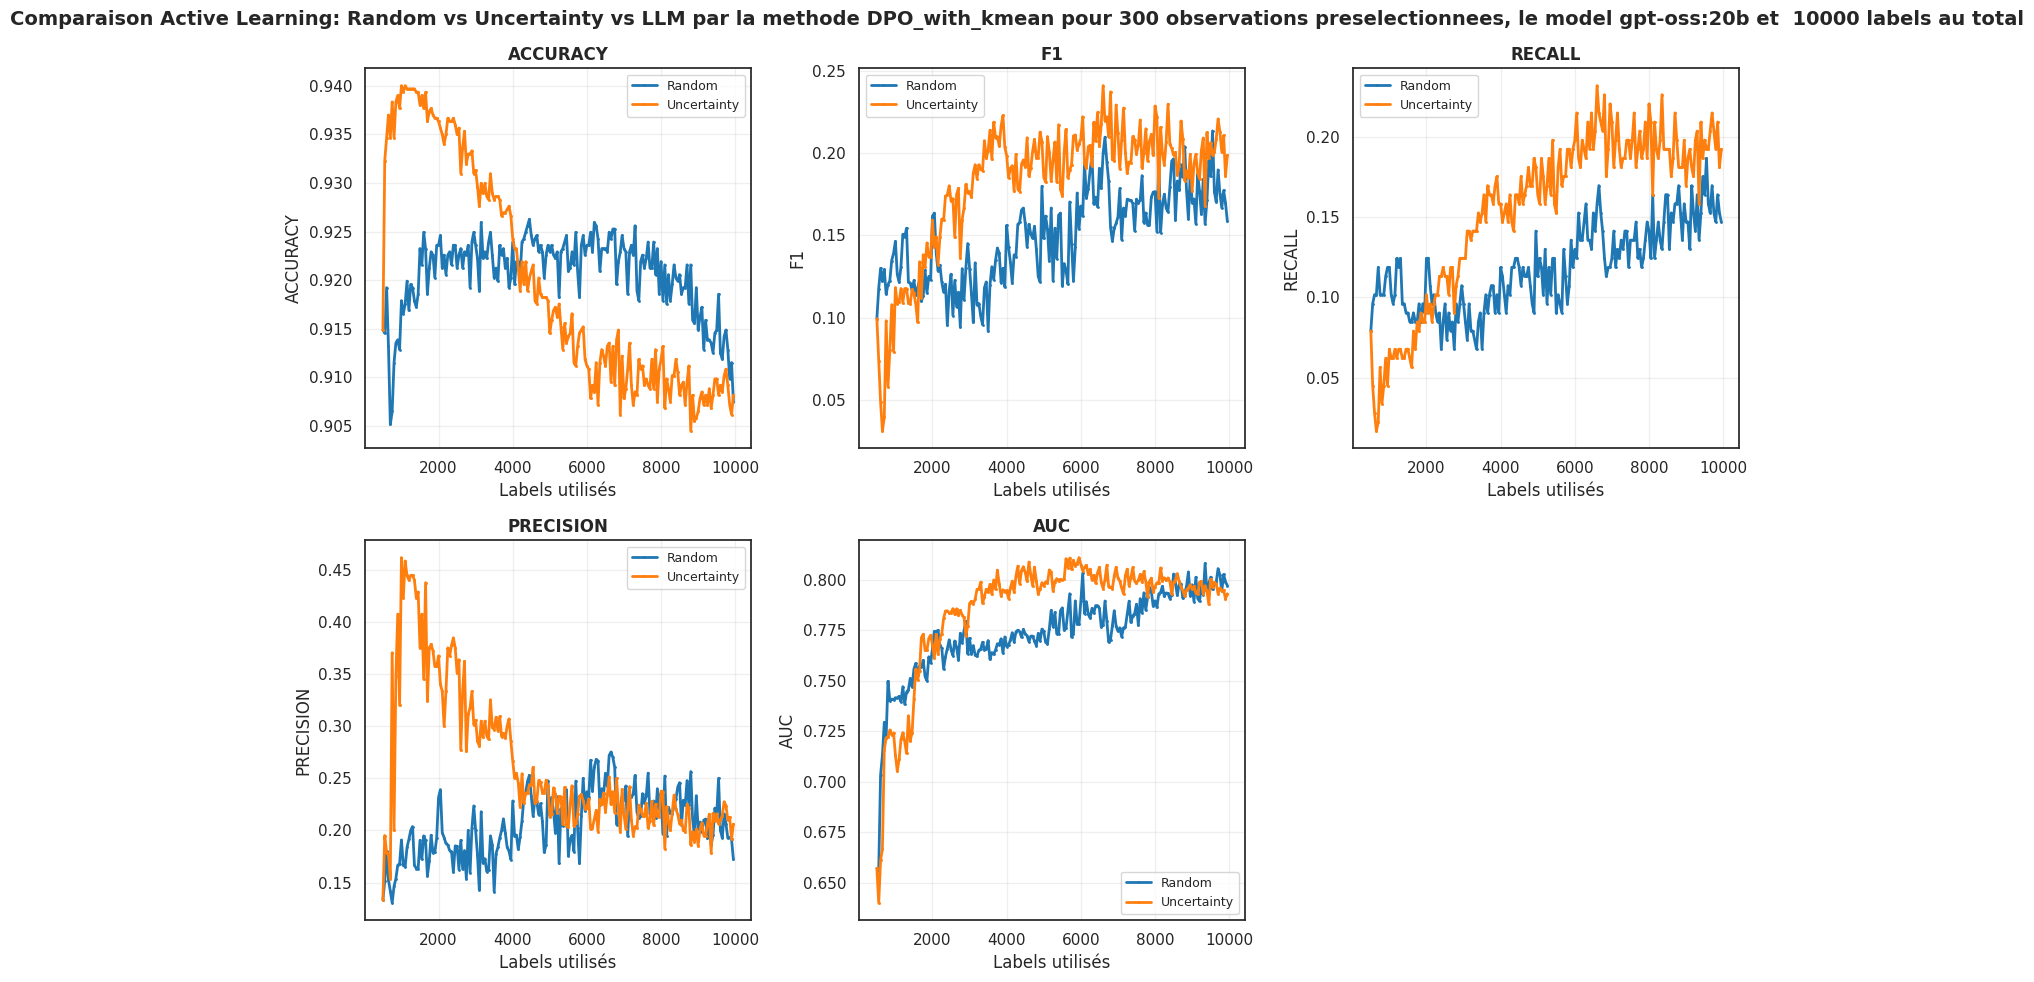

In [316]:
# ===========================
# VISUALISATION
# ===========================
import seaborn as sns
import matplotlib.pyplot as plt

# sns.set_theme(style="white", palette="deep", font_scale=1.0)
# metrics = ["accuracy", "f1", "recall", "precision", "auc"]
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for i, metric in enumerate(metrics):
#     ax = axes[i]
    
#     ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"], 
#             'o-', label="Random", color=colors[0], linewidth=2, markersize=1)
    
#     ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"], 
#             's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=1)
    
#     ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"], 
#             '^-', label="LLM", color=colors[2], linewidth=2, markersize=1)
    
#     ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
#     ax.set_xlabel("Labels utilisés")
#     ax.set_ylabel(metric.upper())
#     ax.legend(loc='best', fontsize=9)
#     ax.grid(True, alpha=0.3)

# fig.delaxes(axes[5])

# plt.suptitle(f"Comparaison Active Learning: Random vs Uncertainty vs LLM par la methode {methode} pour {n_preselect} observations preselectionnees, le model {gpu_model} et  {label_max} labels au total", 
#              fontsize=14, fontweight='bold')
# plt.tight_layout()

# plt.savefig(f"/home/onyxia/PROJET_STATAPP/Notebooks/sorties/active_learning_results_{methode}_{gpu_model}_{n_preselect}_{label_max}_temp_{temperature}.png", dpi=150, bbox_inches='tight')
# print("✓ Graphique sauvegardé: active_learning_results.png")
# plt.show() 

sns.set_theme(style="white", palette="deep", font_scale=1.0)
metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"], 
            'o-', label="Random", color=colors[0], linewidth=2, markersize=1)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"], 
            's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=1)
    
#     ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"], 
#             '^-', label="LLM", color=colors[2], linewidth=2, markersize=1)
    
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle(f"Comparaison Active Learning: Random vs Uncertainty vs LLM par la methode {methode} pour {n_preselect} observations preselectionnees, le model {gpu_model} et  {label_max} labels au total", 
             fontsize=14, fontweight='bold')
plt.tight_layout()

In [317]:
n_select

50

In [318]:
len([84, 127, 243, 362, 442, 523, 604, 685, 766, 847, 928, 1009, 16, 75, 134, 203, 272, 341, 410, 479, 548, 617, 688, 759, 830, 901, 972, 4, 98, 153, 218, 283, 354, 425, 496, 567, 638, 709, 776, 847, 918, 989, 37, 106, 175, 244, 313, 382, 451, 520, 591, 662, 733, 804])

54